In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import math
import warnings

import arviz as az
import emcee

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
# ---------- UQ & prior ----------
sigma_obs = 1e-1
NS_sample = 2
EPS_VAR   = 1e-8     # sàn nhỏ để tránh var_eff ~ 0 (ổn định log)
PI2       = 2.0 * math.pi

cuda


In [3]:
experimanrtal_data_path = "../TED_Temperature.xlsx"
df = pd.read_excel(experimanrtal_data_path)
temperature_columns = df.columns[2:]
temperature_data = df[temperature_columns].T.values#[:2]
temperature_data_mask = ~np.isnan(temperature_data)
temperature_data_mask = temperature_data_mask.flatten()
time_points = df['Time'] # Sau dùng để visulization



print(f'temperature_data shape:{temperature_data.shape}')
print(f'temperature_data_mask shape:{temperature_data_mask.shape}')
print(df.head())

temperature_data shape:(6, 1473)
temperature_data_mask shape:(8838,)
        Time  STT  TED1210_TEM_05  TED1219_TEM_05  TED1250_TEM_01  \
0 2009-07-08    1             NaN             NaN             NaN   
1 2009-07-09    2             NaN             NaN             NaN   
2 2009-07-10    3             NaN             NaN             NaN   
3 2009-07-11    4             NaN             NaN             NaN   
4 2009-07-12    5             NaN             NaN             NaN   

   TED1251_TEM_01  TED1253_TEM_01  TED1258_TEM_01  
0             NaN       21.494342             NaN  
1       21.534905       21.491602             NaN  
2       21.539591       21.497382             NaN  
3       21.550029       21.504905             NaN  
4       21.561187       21.516124             NaN  


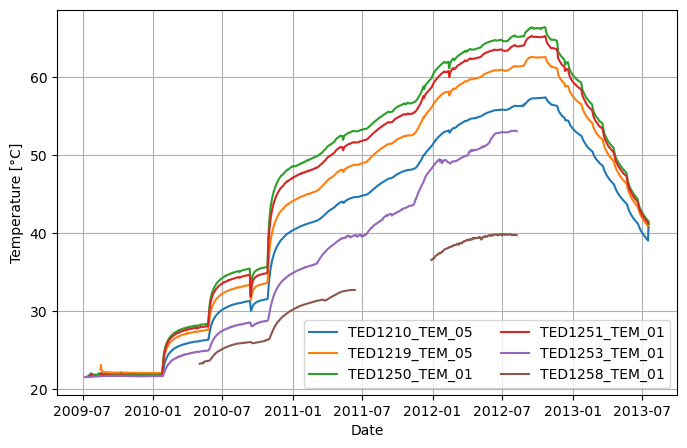

In [5]:
sensors = ["TED1210_TEM_05","TED1219_TEM_05","TED1250_TEM_01","TED1251_TEM_01","TED1253_TEM_01","TED1258_TEM_01"]
plt.figure(figsize=(8, 5))
for i in range(temperature_data.shape[0]):
    plt.plot(df['Time'], temperature_data[i, :], label=f'{sensors[i]}')
plt.xlabel('Date',fontsize=10)
plt.ylabel('Temperature [°C]',fontsize=10)
plt.legend(ncol=2, fontsize=10)
#plt.title('InsituTemperature Data Over Time')
plt.grid(True)
plt.show()

In [7]:
L = 1 # domain
dt = 1 # time step
T = 1473
nt = T/dt
T_MIN = 22.
T_MAX = 90.
CP_MIN = 800.
CP_MAX = 1100.
PS_MIN = 2350.
PS_MAX = 2450.

point_list = np.array([[0.06,0.61],
                      [0.59,0.01],
                      [0.11,0.31],
                      [0.42,0.15],
                      [1.1,0.13],
                      [0.2,1.34]],dtype=np.float32)

In [52]:
# ========= Your spectral block (giữ nguyên) =========
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        self.weights = nn.Parameter(
            torch.randn(in_channels, out_channels, modes, dtype=torch.cfloat) * 0.1
        )

    def compl_mul1d(self, input, weights):
        return torch.einsum("bcn,con->bon", input, weights)

    def forward(self, x):
        B, C, N = x.shape
        x_ft = torch.fft.rfft(x, dim=-1)
        out_ft = torch.zeros(B, self.out_channels, x_ft.shape[-1],
                             dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes] = self.compl_mul1d(x_ft[:, :, :self.modes], self.weights)
        x = torch.fft.irfft(out_ft, n=N, dim=-1)
        return x

# ========= Bayesian 1x1 Conv (variational) =========
class BayesianConv1d(nn.Module):
    """
    1x1 conv variational theo kênh:
      out[b, o, n] = sum_c W[o,c] * x[b,c,n] + b[o]
    W ~ N(mu, sigma^2), sigma = softplus(rho).
    Trả về: out, kl_div (so với prior N(0,1)).
    """
    def __init__(self, in_channels, out_channels, bias=True, prior_mu=0.0, prior_sigma=1.0):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.prior_mu = prior_mu
        self.prior_sigma = prior_sigma

        # Posterior q(W): dùng ma trận [out,in] (không có trục 1 chiều)
        self.weight_mu  = nn.Parameter(torch.empty(out_channels, in_channels))
        self.weight_rho = nn.Parameter(torch.empty(out_channels, in_channels))
        if bias:
            self.bias_mu  = nn.Parameter(torch.empty(out_channels))
            self.bias_rho = nn.Parameter(torch.empty(out_channels))
        else:
            self.register_parameter('bias_mu', None)
            self.register_parameter('bias_rho', None)

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight_mu, a=math.sqrt(5))
        nn.init.constant_(self.weight_rho, -4.0)  # sigma nhỏ ban đầu
        if self.bias_mu is not None:
            bound = 1. / max(1, self.in_channels) ** 0.5
            nn.init.uniform_(self.bias_mu, -bound, bound)
            nn.init.constant_(self.bias_rho, -4.0)

    @staticmethod
    def _softplus(x):
        return F.softplus(x)

    def kl_divergence(self, w_mu, w_sigma, prior_mu, prior_sigma):
        # KL(q||p) từng phần tử Gaussian
        term1 = torch.log(prior_sigma / (w_sigma + 1e-12))
        term2 = (w_sigma**2 + (w_mu - prior_mu)**2) / (2 * (prior_sigma**2))
        kl = (term1 + term2 - 0.5).sum()
        return kl

    def forward(self, x):
        """
        x: [B, C_in, N]
        out: [B, C_out, N]
        """
        B, C, N = x.shape
        device = x.device

        # Sample W, b
        w_sigma = self._softplus(self.weight_rho)
        W = self.weight_mu + w_sigma * torch.randn_like(self.weight_mu, device=device)

        if self.bias_mu is not None:
            b_sigma = self._softplus(self.bias_rho)
            b = self.bias_mu + b_sigma * torch.randn_like(self.bias_mu, device=device)
        else:
            b = None

        # 1x1 conv theo kênh: giữ nguyên N
        # (broadcast b theo N)
        out = torch.einsum('bcn,oc->bon', x, W)
        if b is not None:
            out = out + b.view(1, -1, 1)

        # KL cho W và b
        kl = self.kl_divergence(self.weight_mu, w_sigma,
                                torch.tensor(self.prior_mu, device=device),
                                torch.tensor(self.prior_sigma, device=device))
        if self.bias_mu is not None:
            kl = kl + self.kl_divergence(self.bias_mu, self._softplus(self.bias_rho),
                                         torch.tensor(self.prior_mu, device=device),
                                         torch.tensor(self.prior_sigma, device=device))
        return out, kl

import math

# ========= FNO với Bayesian head xuất (mu, logvar) =========
class FNO1d_Bayes(nn.Module):
    def __init__(self, in_channels, out_channels, modes=12, width=64, prior_sigma=1.0):
        super().__init__()
        self.out_channels = out_channels
        self.fc0 = nn.Conv1d(in_channels, width, 1)  # [B, C_in, N]
        self.conv1 = SpectralConv1d(width, width, modes)
        self.conv2 = SpectralConv1d(width, width, modes)
        self.w1 = nn.Conv1d(width, width, 1)
        self.w2 = nn.Conv1d(width, width, 1)
        self.fc1 = nn.Conv1d(width, 128, 1)

        # Bayesian head: xuất 2*C_out để tách mu và logvar
        self.fc2_bayes = BayesianConv1d(128, 2*out_channels, prior_sigma=prior_sigma)

    def forward(self, x):
        """
        Input:  x [B, C_in, N]
        Output: mu [B, C_out, N], logvar [B, C_out, N], kl (scalar tensor)
        """
        x = self.fc0(x)
        x1 = self.conv1(x); x2 = self.w1(x); x = F.gelu(x1 + x2)
        x1 = self.conv2(x); x2 = self.w2(x); x = F.gelu(x1 + x2)
        x = F.gelu(self.fc1(x))

        out, kl = self.fc2_bayes(x)  # [B, 2*C_out, N]
        mu, logvar = torch.split(out, self.out_channels, dim=1)
        # Stabilize logvar (optional clamp)
        logvar = torch.clamp(logvar, min=-15.0, max=-10.0)
        return mu, logvar, kl

# ========= Predictive distribution qua MC sampling ========

    @torch.no_grad()
    def mc_predict(model, x, T=16):
        """
        Inference T sample ( each sampe is drawned from p(w|D)).
        Return:
          pred_mean  [B,C,N]        = E_q[μ]
          ale_var    [B,C,N]        = E_q[σ²]
          epi_var    [B,C,N]        = Var_q[μ]
          total_var  [B,C,N]        = ale_var + epi_var
        """
        mus = []
        vars_ = []
        for _ in range(T):
            mu, logvar, _ = model(x)
            mus.append(mu)
            vars_.append(torch.exp(logvar))
        mus = torch.stack(mus, dim=0)  # [T,B,C,N]
        vars_ = torch.stack(vars_, dim=0)

        pred_mean = mus.mean(0)
        ale_var = vars_.mean(0)
        epi_var = mus.var(0, unbiased=False)
        total_var = ale_var + epi_var
        return mus, ale_var, epi_var, total_var

def standardize_tensor(tensor, T_min=22., T_max=100.):
  """Standardizes a tensor to [0, 1] using min-max scaling."""
  return (tensor - T_min) / (T_max - T_min)

def destandardize_tensor(tensor, T_min = 22., T_max = 100.):
  """Destandardizes a tensor from [0, 1] to its original range."""
  return tensor * (T_max - T_min) + T_min

In [54]:
INPUT = 6
OUTPUT = 1473
model_path = './fno1d_bayes_model.pt'
fw_model = FNO1d_Bayes(in_channels=INPUT, out_channels=OUTPUT, modes=4, width=256, prior_sigma=1e-5).to(device)
if torch.cuda.is_available():
  fw_model.load_state_dict(torch.load(model_path)['model_state'])
else:
  fw_model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu'))['model_state'])

def predict_single_sample_mc(model, sample_x, device, T_MIN=22., T_MAX=90.):
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation
        # Add a batch dimension and move to the correct device
        sample_x = sample_x.unsqueeze(0).to(device)

        mean_pred,_, _, var_pred = FNO1d_Bayes.mc_predict(model, sample_x, T=NS_sample)
        mean_pred = mean_pred.cpu()
        var_pred = var_pred.cpu()

        mean = destandardize_tensor(mean_pred, T_MIN, T_MAX)
        var = var_pred*(T_MAX-T_MIN)**2
    return mean.permute(0, 3, 2, 1).squeeze(-1).numpy(), var.squeeze(0).permute(1, 0).numpy()

def Surrogate(model, point_list, params):
    """
    Chạy surrogate để dự báo nhiệt độ tại các điểm/ thời điểm cần quan sát.
    - Chuẩn hóa đầu vào giống lúc train.
    - Chỉ trả về các vị trí có mask temperature_data_mask.
    """
    params_tensor = torch.tensor(params, dtype=torch.float32)

    new_point_list = []
    for i in range(point_list.shape[0]):
        p = torch.tensor(point_list[i], dtype=torch.float32)
        # (2,) + (4,) -> (6,)
        combined = torch.cat([p, params_tensor], dim=0)
        new_point_list.append(combined)

    X_BI_test = torch.stack(new_point_list)      # (n_points, 6)
    X = X_BI_test.permute(1, 0).to(device)       # (6, n_points)

    # Chuẩn hóa theo quy ước khi train
    X[0:2, :] = X[0:2, :] / L
    X[2:3, :] = standardize_tensor(X[2:3, :], 0.8, 2.5)
    X[3:4, :] = standardize_tensor(X[3:4, :], 1.1, 2.5)
    X[4:5, :] = standardize_tensor(X[4:5, :], PS_MIN, PS_MAX)
    X[5:6, :] = standardize_tensor(X[5:6, :], CP_MIN, CP_MAX)
    # Dự báo
    # y_pred_ensemble, var_pred_ensemble shape [6,1473]
    y_pred_ensemble, var_pred_ensemble = predict_single_sample_mc(model, X, device=device)
    '''print(y_pred_ensemble.shape)
    plt.figure(figsize=(8, 5))
    for i in range(y_pred_ensemble.shape[0]):
        for j in range(y_pred_ensemble.shape[1]):
            plt.plot(time_points, y_pred_ensemble[i,j, :], label=f'{sensors[i]}')
        plt.plot(time_points, temperature_data[i, :], label=f'{sensors[i]}')
    plt.show()'''
    # Drawn random y from distribution of y prediction:
    #Z = 0.5*np.random.randn(NS_sample, 1, 1) 
    #y_std = np.sqrt(var_pred_ensemble)
    #y_samples shape (NS_sample, 6, 1473)
    #y_samples = y_pred_ensemble + y_std * Z

    y_samples = y_pred_ensemble.reshape(NS_sample, -1)

    y_samples = y_samples.reshape(y_samples.shape[0], -1)
    y_samples_masked = y_samples[:, temperature_data_mask]



    return y_samples_masked

In [56]:

# ---------- Prior trong không gian z ----------
def log_prior(z):
    z = np.asarray(z, dtype=float)
    if np.any(np.abs(z) > 5):
        return -np.inf
    # prior N(0,1) độc lập từng chiều (bỏ hằng số)
    return -0.5 * np.sum(z**2)

# ================== LIKELIHOOD CHO MỘT θ^(s) (E-Post) ==================
def _loglik_given_s(u_obs, pred_s, sigma_obs):
    """
    u_obs : (N_obs,)
    pred_s: (N_obs,)  -- dự đoán từ surrogate ứng với θ^(s)
    sigma_obs: scalar
    """
    resid = u_obs - pred_s
    if not np.all(np.isfinite(resid)):
        return -np.inf
    var = max(sigma_obs**2, EPS_VAR)
    N   = u_obs.shape[0]
    ll  = -0.5 * (np.sum(resid * resid / var) + N * np.log(PI2 * var))
    return float(ll)

def make_log_posterior_given_s(s_index):
    """
    Trả về một hàm log_posterior(z) cố định θ^(s_index).
    Mỗi lần gọi sẽ:
      - unpack z -> (params, sigma_obs)
      - gọi Surrogate(point_list, params) -> (S, N_obs), rồi lấy hàng s_index
      - tính loglik với pred_s đó + prior
    """
    def log_posterior_s(z):
        # PRIOR
        lp = log_prior(z)
        if not np.isfinite(lp):
            return -np.inf

        # UNPACK & BOUNDS
        params = prior_mean + np.asarray(z) * prior_std
        if (np.any(params < lower_bounds)) or (np.any(params > upper_bounds)):
            return -np.inf

        # PREDICT từ surrogate: yêu cầu trả [S, N_obs]

        pred_s_all = Surrogate(fw_model,point_list, params)  # (S, N_obs)
        
        if pred_s_all is None or pred_s_all.ndim != 2:
            return -np.inf
        S, Nobs = pred_s_all.shape
        if Nobs != u_obs.shape[0]:
            return -np.inf
        if not (0 <= s_index < S):
            return -np.inf

        pred_s = pred_s_all[s_index]  # (N_obs,)

        # LOG-LIKELIHOOD CHO θ^(s)
        ll = _loglik_given_s(u_obs, pred_s, sigma_obs)
        if not np.isfinite(ll):
            return -np.inf
        return lp + ll
    return log_posterior_s

# ================== CHẠY E-POST: S chuỗi MCMC rồi TRỘN ==================
def run_epost_emcee(
    S,
    n_walkers, n_params,
    n_steps, burn_in=100, thin_step=10,
    init_scale=0.1,
    moves=None,
    random_state=2025,
):
    """
    Chạy E-Post với S thành phần (θ^(s)), mỗi thành phần 1 run emcee.
    Trả về:
      - samples_mix: (Tổng_mẫu, n_params)  -- mixture posterior (ghép tất cả chuỗi)
      - all_samplers: list các sampler (để bạn xem thêm diagnostics)
    """
    rng = np.random.default_rng(random_state)
    if moves is None:
        moves = [(emcee.moves.StretchMove(a=2.0), 0.6),
                 (emcee.moves.DEMove(),               0.3),
                 (emcee.moves.DESnookerMove(),        0.1)]

    samples_all = []
    all_samplers = []

    print(f"🔁 Running E-Post with S = {S} components ...")
    t0 = time.time()

    # Khởi tạo cho từng thành phần (có thể dùng cùng init hoặc random khác nhau)
    for s in range(S):
        print(f"  → Component s = {s+1}/{S}")
        # tạo log_posterior cố định θ^(s)
        log_post_s = make_log_posterior_given_s(s)

        # init walkers quanh 0 (z-space) để hợp prior N(0, I)
        initial_z = init_scale * rng.normal(0.0, 1.0, size=(n_walkers, n_params))

        sampler_s = emcee.EnsembleSampler(n_walkers, n_params, log_post_s, moves=moves)
        sampler_s.run_mcmc(initial_z, n_steps, progress=False)
        all_samplers.append(sampler_s)

        # Lấy mẫu sau burn/thin
        chain_s = sampler_s.get_chain(discard=burn_in, thin=thin_step, flat=True)  # (Nsamples_s, n_params)
        samples_all.append(chain_s)

    t1 = time.time()
    print(f"✅ E-Post done in {t1 - t0:.2f}s")

    # Mixture posterior = ghép tất cả mẫu (trọng số đều 1/S)
    samples_mix = np.concatenate(samples_all, axis=0)
    return samples_mix, all_samplers

#Preparing Experimental Data

In [70]:
# ---------- Prior thông số vật lý (bạn đã khai báo ở cuối – giữ nguyên) ----------
PS_mean = 2420
PS_std  = 40.0
CP_mean = 978
CP_std  = 70.0

prior_mean   = np.array([1.31, 1.5, PS_mean, CP_mean], dtype=float)
prior_std    = np.array([2.5e-1, 2.5e-1, PS_std,  CP_std ], dtype=float)
lower_bounds = np.array([0.8,  1.1,  PS_MIN,  CP_MIN], dtype=float)
upper_bounds = np.array([2.0,  2.5,  PS_MAX+50,  CP_MAX], dtype=float)

# ---------- Dữ liệu quan sát ----------
u_obs = temperature_data.flatten()[temperature_data_mask]
# ---------- Thiết lập MCMC ----------
n_params      = 4
n_walkers     = 8 * n_params       # quy tắc emcee: >= 2*ndim; dùng nhiều hơn để ổn định
n_steps       = 5_00
burn_in       = 1_0
thin_step     = 1


In [90]:
ndim = 4
sigma = 0.02  # bước ~2% range

cov = (sigma**2) * np.eye(ndim)

S = NS_sample  # số mẫu θ mà surrogate sinh ra mỗi lần (ví dụ 15, 30, ...)
samples_mix, samplers = run_epost_emcee(
    S=S,
    n_walkers=n_walkers,
    n_params=n_params,
    n_steps=n_steps,
    burn_in=burn_in,
    thin_step=thin_step,
    init_scale=0.1,
    moves = [
        # Bước random-walk rất nhỏ quanh vị trí hiện tại
        (emcee.moves.GaussianMove(cov), 0.5),
    
        # Ensemble move, bước vừa phải
        (emcee.moves.StretchMove(a=1.1), 0.4),
    
        # Một ít global move để không bị kẹt
        (emcee.moves.DEMove(),0.1)],
    random_state=42,
)
print("Mixture posterior shape:", samples_mix.shape)


🔁 Running E-Post with S = 2 components ...
  → Component s = 1/2
  → Component s = 2/2
✅ E-Post done in 316.72s
Mixture posterior shape: (31360, 4)


Acceptance (per walker): [0.042 0.018 0.03  0.058 0.05  0.032 0.038 0.044 0.042 0.03  0.052 0.042
 0.05  0.03  0.064 0.018 0.038 0.02  0.042 0.04  0.028 0.038 0.052 0.038
 0.016 0.024 0.036 0.046 0.022 0.042 0.01  0.062]
🧹 Số walker bị loại bỏ: 0 / 32
----- Posterior summary -----
Param θ1: Mean = 1.269307e+00,  SD = 3.529156e-02
Param θ2: Mean = 1.494778e+00,  SD = 5.759549e-02
Param θ3: Mean = 2.426035e+03,  SD = 1.202098e+01
Param θ4: Mean = 1.020700e+03,  SD = 4.735751e+01


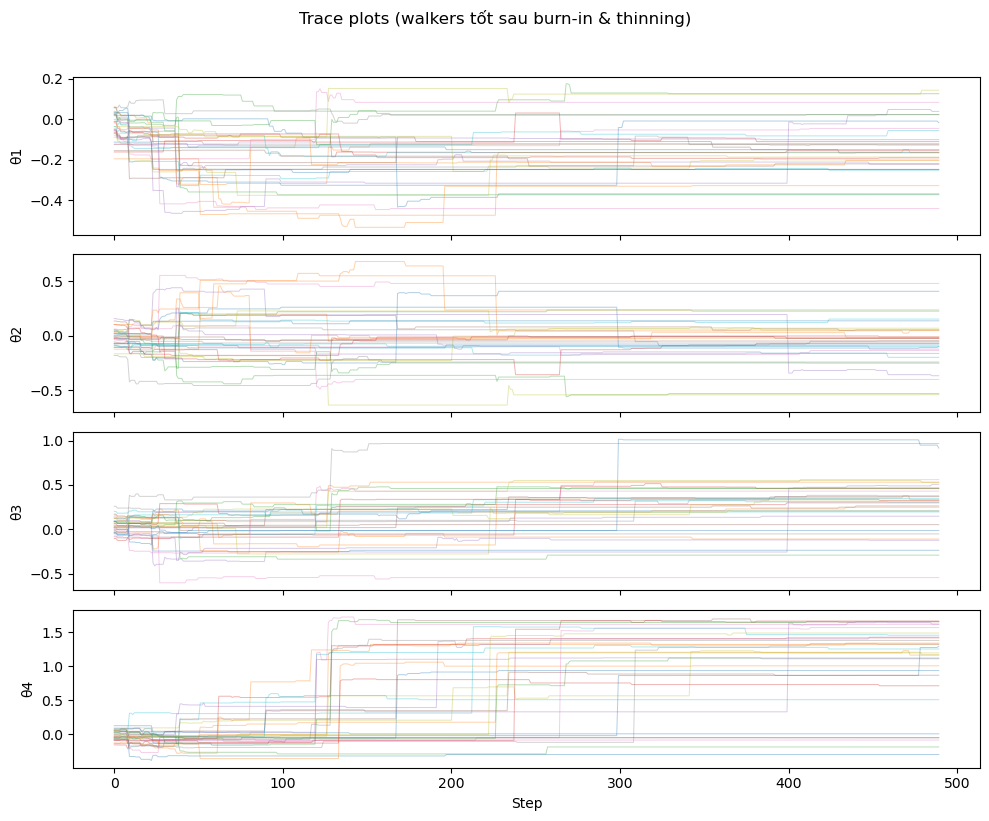

Acceptance (per walker): [0.03  0.042 0.036 0.04  0.034 0.06  0.022 0.058 0.012 0.04  0.04  0.044
 0.048 0.042 0.058 0.044 0.042 0.048 0.042 0.02  0.036 0.046 0.066 0.036
 0.056 0.028 0.044 0.012 0.032 0.048 0.044 0.034]
🧹 Số walker bị loại bỏ: 0 / 32
----- Posterior summary -----
Param θ1: Mean = 1.254860e+00,  SD = 3.810214e-02
Param θ2: Mean = 1.514004e+00,  SD = 8.148637e-02
Param θ3: Mean = 2.417147e+03,  SD = 1.151073e+01
Param θ4: Mean = 1.021143e+03,  SD = 4.563103e+01


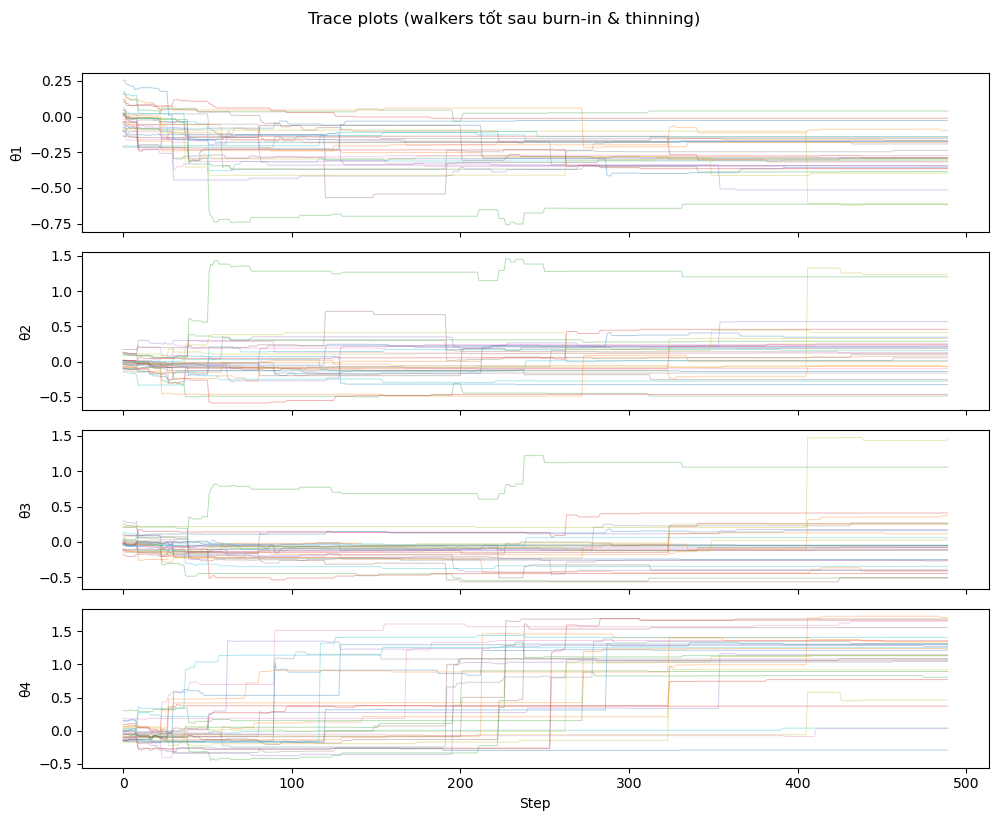

In [92]:
# ---------- Chẩn đoán nhanh ----------
for sampler in samplers:
    acceptance_fraction = sampler.acceptance_fraction
    print("Acceptance (per walker):", np.round(acceptance_fraction, 3))
    
    threshold = 3e-3                      # loại walker gần như không chấp nhận
    burn_in = 10
    good_walkers = np.where(acceptance_fraction >= threshold)[0]
    bad_walkers  = np.where(acceptance_fraction <  threshold)[0]
    print(f"🧹 Số walker bị loại bỏ: {len(bad_walkers)} / {n_walkers}")
    
    # Lấy chuỗi sau burn-in + thinning, chỉ giữ walker tốt
    chain_all = sampler.get_chain(discard=burn_in, thin=thin_step, flat=False)   # (steps, walkers, params)
    chain_good = chain_all[:, good_walkers, :]                                   # (steps, good_walkers, params)
    
    # ---------- Đưa về không gian tham số gốc để báo cáo ----------
    samples_z = chain_good.reshape(-1, n_params)
    z_phys  = samples_z[:, :4]

    
    # 4 tham số vật lý
    samples_params = z_phys * prior_std + prior_mean

    
    # ---------- Thống kê hậu nghiệm ----------
    mean_params = np.mean(samples_params, axis=0)
    std_params  = np.std(samples_params, axis=0, ddof=1)

    
    print("----- Posterior summary -----")
    for i in range(4):
        print(f"Param θ{i+1}: Mean = {mean_params[i]:.6e},  SD = {std_params[i]:.6e}")
    
    # ---------- Trace plots ----------
    param_names = [f"θ{i+1}" for i in range(4)]
    fig, axes = plt.subplots(n_params, figsize=(10, 2.0 * n_params), sharex=True)
    for j in range(n_params):
        for w in range(chain_good.shape[1]):
            axes[j].plot(chain_good[:, w, j], alpha=0.35, lw=0.7)
        axes[j].set_ylabel(param_names[j])
    axes[-1].set_xlabel("Step")
    plt.suptitle("Trace plots (walkers tốt sau burn-in & thinning)", y=1.02)
    plt.tight_layout()
    plt.show()

In [94]:

z_phys  = samples_mix[:, :4]
# 4 tham số vật lý
samples_params = z_phys * prior_std + prior_mean
# ---------- Thống kê hậu nghiệm ----------
mean_params = np.mean(samples_params, axis=0)
std_params  = np.std(samples_params, axis=0, ddof=1)
print("----- Posterior summary -----")
for i in range(4):
    print(f"Param θ{i+1}: Mean = {mean_params[i]:.6e},  SD = {std_params[i]:.6e}")



----- Posterior summary -----
Param θ1: Mean = 1.262083e+00,  SD = 3.742687e-02
Param θ2: Mean = 1.504391e+00,  SD = 7.121018e-02
Param θ3: Mean = 2.421591e+03,  SD = 1.257953e+01
Param θ4: Mean = 1.020922e+03,  SD = 4.650207e+01


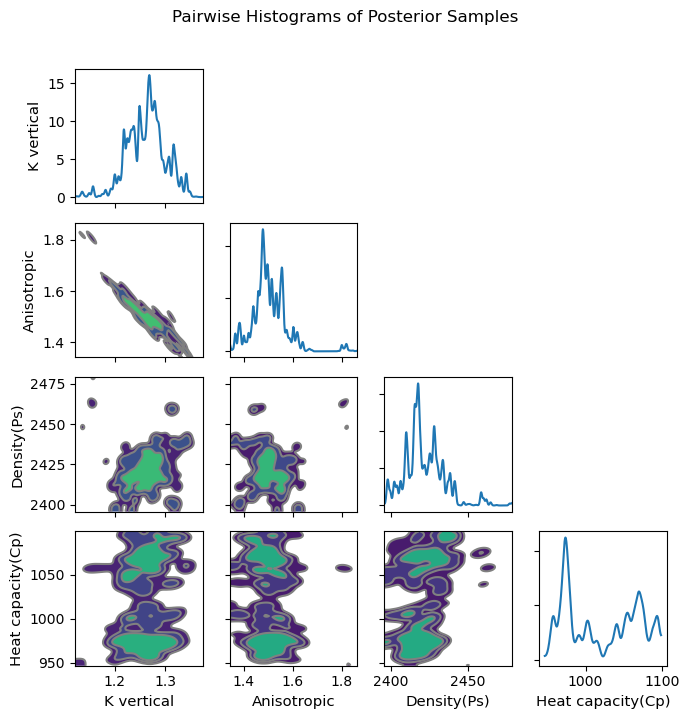

In [96]:
import arviz as az
import matplotlib.pyplot as plt

param_names_real = ["K vertical", "Anisotropic", "Density(Ps)", "Heat capacity(Cp)"]

posterior_params_dict = {param_names_real[i]: samples_params[:, i].reshape(1, -1) for i in range(samples_params.shape[1])}

idata_params = az.from_dict(
    posterior=posterior_params_dict,
    coords={"chain": [0], "draw": np.arange(posterior_params_dict['K vertical'].shape[1])},
    dims={"K vertical": [], "Anisotropic": [], "Density(Ps)": [], "Heat capacity(Cp)": []}
)

# Plot pairwise distributions using plot_pair
az.plot_pair(idata_params, kind='kde', marginals=True, textsize=10, figsize=(7, 7))
plt.suptitle("Pairwise Histograms of Posterior Samples", y=1.02)
plt.tight_layout()
plt.show()

In [80]:
sensor_slices = []
current_masked_index = 0
# Reshape the mask to match the original temperature_data shape (num_sensors, num_time_points)
temperature_data_mask_reshaped = temperature_data_mask.reshape(temperature_data.shape)

for i in range(temperature_data_mask_reshaped.shape[0]):
    # Count the number of True values for the current sensor in the mask
    num_masked_points_for_sensor = np.sum(temperature_data_mask_reshaped[i, :])

    # Define the slice for the current sensor in the flattened masked data (u_obs)
    start_index = current_masked_index
    end_index = current_masked_index + num_masked_points_for_sensor
    sensor_slices.append(slice(start_index, end_index))

    # Update the current index for the next sensor
    current_masked_index = end_index



In [82]:

# 1) Dự báo surrogate cho từng mẫu và ghép sigma_eff tương ứng
pred_list = []
sigma_eff_list = []
keep_count = 0

S_total = samples_params.shape[0]
print(f"Generating posterior predictive for {S_total} posterior samples...")

for i, params in enumerate(samples_params):
    # bỏ mẫu ngoài bounds để tránh lỗi surrogate
    if np.any(params < lower_bounds) or np.any(params > upper_bounds):

        continue

    pred = Surrogate(fw_model, point_list, params)
    if pred is None:

        continue
    if isinstance(pred, torch.Tensor):
        pred = pred.detach().cpu().numpy()
    pred_mean = pred.mean(axis=0)
    pred_var = pred.var(axis=0)
    # kiểm tra shape

    pred_list.append(pred_mean)
    # sigma_eff cho mẫu này
    sigma_eff_list.append(np.sqrt(pred_var))
    keep_count += 1

    if (i+1) % 1000 == 0:
        print(f"  processed {i+1}/{S_total} samples...")

if keep_count == 0:
    raise RuntimeError("Không có mẫu hợp lệ để tính PPI (kiểm tra bounds/shape).")

pred_array = np.stack(pred_list, axis=0)                 # (S_keep, N)
sigma_eff = np.stack(sigma_eff_list, axis=0)              # (S_keep, N)
#sigma_eff = np.asarray(sigma_eff_list).reshape(-1, 1)    # (S_keep, 1)
print("Shapes:", pred_array.shape, sigma_eff.shape)

Generating posterior predictive for 31360 posterior samples...
  processed 1000/31360 samples...
  processed 2000/31360 samples...
  processed 3000/31360 samples...
  processed 4000/31360 samples...
  processed 5000/31360 samples...
  processed 6000/31360 samples...
  processed 7000/31360 samples...
  processed 8000/31360 samples...
  processed 9000/31360 samples...
  processed 10000/31360 samples...
  processed 11000/31360 samples...
  processed 12000/31360 samples...
  processed 13000/31360 samples...
  processed 14000/31360 samples...
  processed 15000/31360 samples...
  processed 16000/31360 samples...
  processed 17000/31360 samples...
  processed 18000/31360 samples...
  processed 19000/31360 samples...
  processed 20000/31360 samples...
  processed 21000/31360 samples...
  processed 22000/31360 samples...
  processed 23000/31360 samples...
  processed 24000/31360 samples...
  processed 25000/31360 samples...
  processed 26000/31360 samples...
  processed 27000/31360 samples...
 

In [84]:

noise = np.random.normal(loc=0.0, scale=sigma_eff, size=pred_array.shape)
y_rep = pred_array + noise                                # (S_keep, N)

# 3) Tính PPI 95% theo trục mẫu
ppi_low  = np.quantile(y_rep, 0.025, axis=0)              # (N,)
ppi_high = np.quantile(y_rep, 0.975, axis=0)              # (N,)

# Tính mean của dự báo "không noise" để vẽ
mean_pred = pred_array.mean(axis=0)

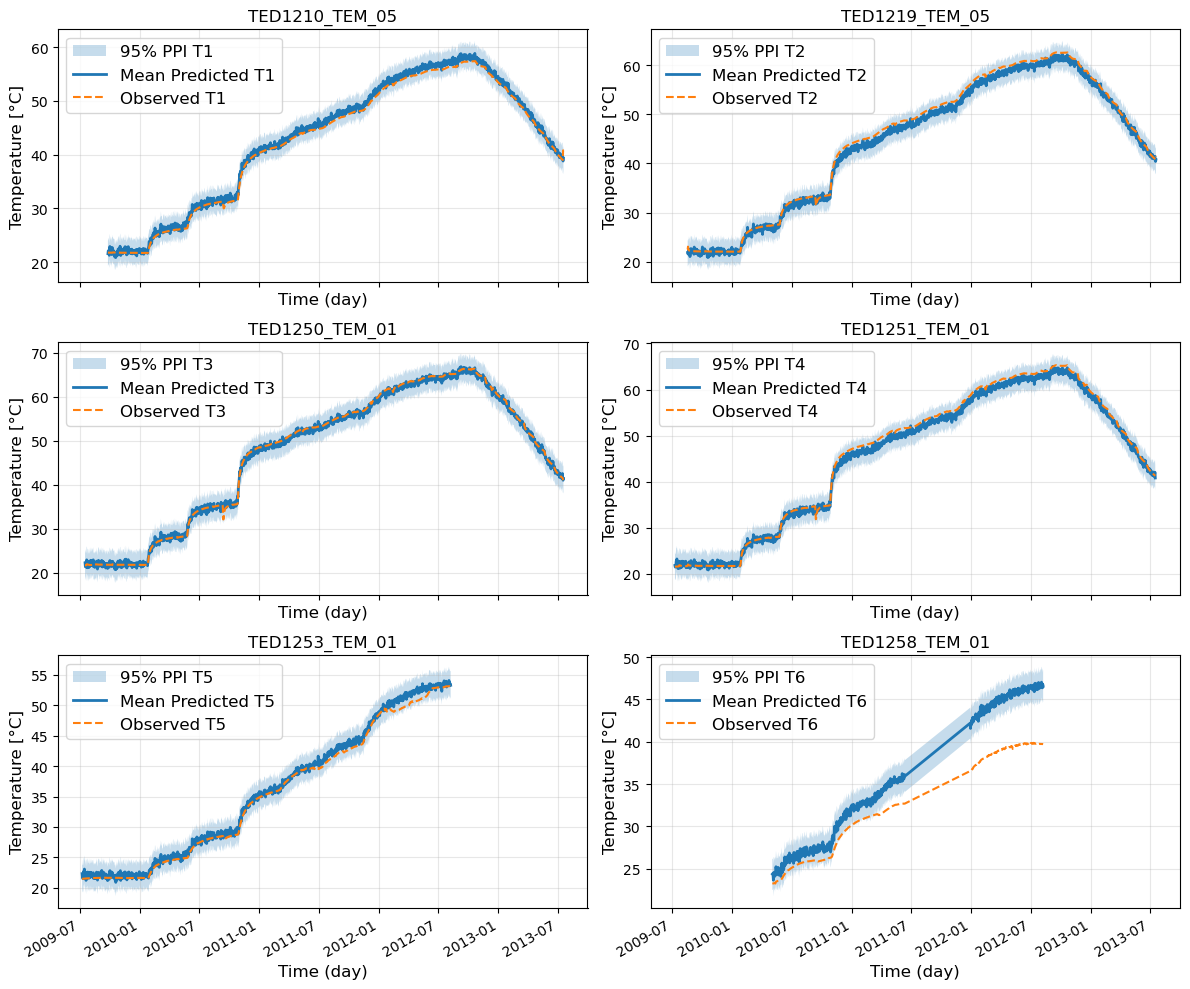

Coverage T1: 100.0%
Coverage T2: 100.0%
Coverage T3: 100.0%
Coverage T4: 100.0%
Coverage T5: 99.6%
Coverage T6: 41.0%


In [85]:

labels = [f"T{i+1}" for i in range(6)]

# Create the plot
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()
for k, slc in enumerate(sensor_slices):
    ax = axes[k]
    obs_k  = u_obs[slc]
    mean_k = mean_pred[slc]
    low_k  = ppi_low[slc]
    high_k = ppi_high[slc]
    # Use the corresponding time points for this sensor's data
    t_k    = time_points[temperature_data_mask.reshape(temperature_data.shape)[k, :]]


    # dải PPI
    ax.fill_between(t_k, low_k, high_k, alpha=0.25, label=f"95% PPI {labels[k]}")
    # mean
    ax.plot(t_k, mean_k, lw=2, label=f"Mean Predicted {labels[k]}")
    # observed
    ax.plot(t_k, obs_k, ls="--", lw=1.5, label=f"Observed {labels[k]}")

    ax.set_title(f"{sensors[k]}")
    ax.set_xlabel("Time (day)",fontsize=12)
    ax.set_ylabel("Temperature [°C]",fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=1, fontsize=12)

    for label in ax.get_xticklabels():
            label.set_rotation(30)
            label.set_horizontalalignment('right')
plt.tight_layout()
plt.show()

# Coverage theo từng cảm biến (tùy chọn)
for k, slc in enumerate(sensor_slices):
    cover_k = np.mean((u_obs[slc] >= ppi_low[slc]) & (u_obs[slc] <= ppi_high[slc]))
    print(f"Coverage {labels[k]}: {cover_k*100:.1f}%")

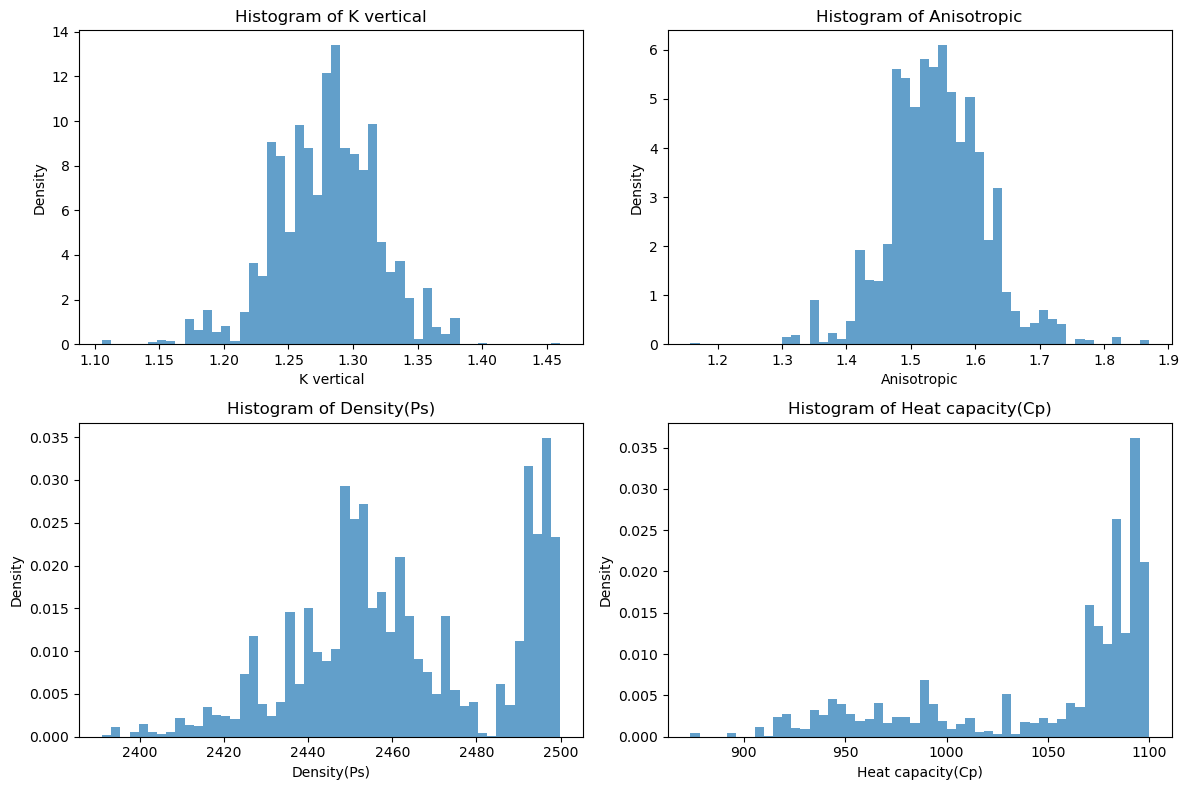

In [88]:
param_names_real = ["K vertical", "Anisotropic", "Density(Ps)", "Heat capacity(Cp)"] # Assuming 4 parameters

plt.figure(figsize=(12, 8))
for i in range(samples_params.shape[1]):
    plt.subplot(2, 2, i + 1) # Arrange in a 2x2 grid
    plt.hist(samples_params[:, i], bins=50, density=True, alpha=0.7)
    plt.xlabel(param_names_real[i])
    plt.ylabel("Density")
    plt.title(f"Histogram of {param_names_real[i]}")

plt.tight_layout()
plt.show()